# Probabilities through the Earth

Putting PREM and the slab machinery together: oscillations for neutrinos that have crossed the Earth, and between two points on its surface.

In [1]:
import sys
import os

# Works whether or not the package is installed: the notebooks sit one level
# below the repository root, as the worked examples in test/ do.
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import matplotlib.pyplot as plt

import globaldefs as gd
import oscprob2nu
import oscprob3nu
import hamiltonians2nu
import hamiltonians3nu

%matplotlib inline
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 90,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11, 'legend.frameon': False})

# The three-flavor vacuum Hamiltonian at the NuFit best fit, normal ordering.
# It is energy-independent; dividing by the energy is what the builders do.
H_VAC_3NU = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, gd.DCP_NO_BF,
    gd.D21_NO_BF, gd.D31_NO_BF)

KM = gd.CONV_KM_TO_INV_EV      # multiply a length in km to get eV^-1
GEV = 1.0e9                    # multiply an energy in GeV to get eV

In [2]:
import earth

## Against zenith angle

At fixed energy, sweeping $\cos\theta_z$ from $0$ (horizontal) to $-1$ (straight through the centre) traces out the matter effect as the neutrino passes through progressively denser material.

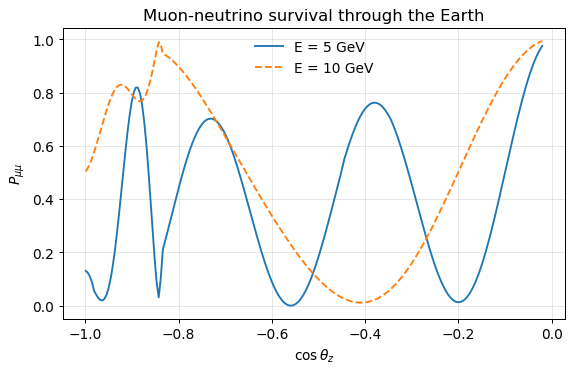

In [3]:
costhz = np.linspace(-0.999, -0.02, 220)

for e_gev, style in ((5.0, "-"), (10.0, "--")):
    p = np.array([earth.probabilities_3nu_earth(
        H_VAC_3NU, e_gev*GEV, c, n_slabs_per_segment=6)
        for c in costhz])
    plt.plot(costhz, p[:, 4], style,
             label="E = %.0f GeV" % e_gev)

plt.xlabel(r"$\cos\theta_z$")
plt.ylabel(r"$P_{\mu\mu}$")
plt.title("Muon-neutrino survival through the Earth")
plt.legend()
plt.show()

The core-mantle boundary leaves a visible feature: near $\cos\theta_z \approx -0.83$ the trajectory starts to clip the outer core, and the density it crosses jumps.

## An Earth oscillogram

Energy against zenith angle — the map an atmospheric-neutrino experiment measures. Each point is a full slab calculation, so this one does loop; the grid is kept modest for that reason.

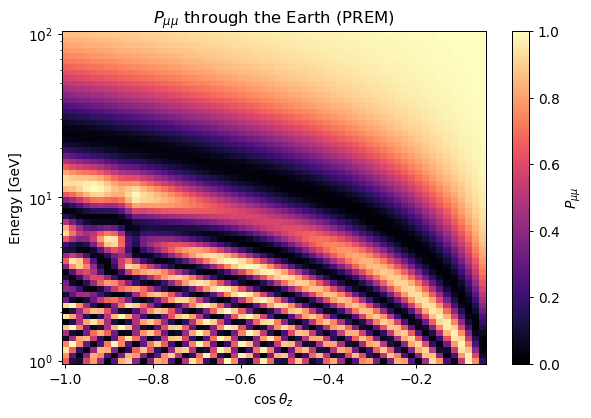

In [4]:
n_e, n_c = 60, 60
E_gev = np.logspace(0.0, 2.0, n_e)
cz = np.linspace(-0.999, -0.05, n_c)

grid = np.empty((n_e, n_c))
for i, e in enumerate(E_gev):
    for j, c in enumerate(cz):
        grid[i, j] = earth.probabilities_3nu_earth(
            H_VAC_3NU, e*GEV, c, n_slabs_per_segment=4)[4]

fig, ax = plt.subplots(figsize=(7.6, 4.8))
mesh = ax.pcolormesh(cz, E_gev, grid, shading="auto",
                     cmap="magma", vmin=0.0, vmax=1.0)
ax.set_yscale("log")
ax.set_xlabel(r"$\cos\theta_z$")
ax.set_ylabel("Energy [GeV]")
ax.set_title(r"$P_{\mu\mu}$ through the Earth (PREM)")
ax.grid(False)
fig.colorbar(mesh, ax=ax, label=r"$P_{\mu\mu}$")
plt.show()

## Between two places

The library knows a set of named locations — the same set as the sibling Magnus package — and will work out the chord between any two of them.

In [5]:
print("known locations:")
print("  " + ", ".join(sorted(earth.LOC_COORDS_DMS)))

known locations:
  baikal, cern, desy, ess, fermilab, gran_sasso, homestake, kamioka, km3net_arca, km3net_orca, north_pole, pyhaasalmi, snolab, south_pole, tokai


In [6]:
pairs = [("cern", "gran_sasso"),
         ("fermilab", "homestake"),
         ("tokai", "kamioka"),
         ("cern", "kamioka"),
         ("south_pole", "north_pole")]

print("%-26s %10s %12s" % ("baseline", "chord [km]", "cos(theta_z)"))
for a, b in pairs:
    la, lo = earth.coordinates_of_named_location(a)
    lb, ob = earth.coordinates_of_named_location(b)
    d = earth.chord_length_inside_earth(la, lo, lb, ob)
    c = earth.costhz_between_points_on_surface(la, lo, lb, ob)
    print("%-26s %10.1f %12.4f" % (a+" -> "+b, d, c))

baseline                   chord [km] cos(theta_z)
cern -> gran_sasso              728.6      -0.0572
fermilab -> homestake          1284.7      -0.1008
tokai -> kamioka                294.7      -0.0231
cern -> kamioka                8726.9      -0.6849
south_pole -> north_pole      12742.0      -1.0000


These are a check on the geometry, not just a convenience. The chords come out at the baselines the experiments actually quote: CERN to Gran Sasso is the 730 km of CNGS, Tokai to Kamioka the 295 km of T2K, and pole to pole is exactly one Earth diameter. Fermilab to Homestake gives 1285 km against DUNE's quoted 1300 km, the difference being that DUNE quotes the distance to the detector hall rather than the surface chord.

And the probability along one of those trajectories, against energy:

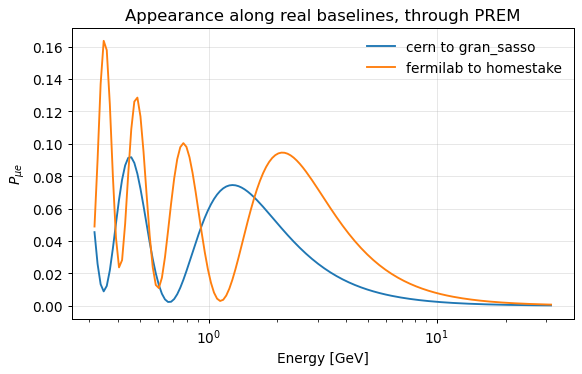

In [7]:
E_gev = np.logspace(-0.5, 1.5, 150)

fig, ax = plt.subplots()
for a, b in (("cern", "gran_sasso"), ("fermilab", "homestake")):
    p = np.array([earth.probabilities_3nu_between_locations(
        H_VAC_3NU, e*GEV, a, b, n_slabs_per_segment=6)
        for e in E_gev])
    ax.semilogx(E_gev, p[:, 3], label="%s to %s" % (a, b))

ax.set_xlabel("Energy [GeV]")
ax.set_ylabel(r"$P_{\mu e}$")
ax.set_title("Appearance along real baselines, through PREM")
ax.legend()
plt.show()